### set up

In [ ]:
!pip install photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

from astropy.io import fits
from astropy.visualization import ZScaleInterval, SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
import astropy.coordinates as astcoo
import astropy.units as u
import astropy.wcs

from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_threshold
from photutils.aperture import CircularAperture, aperture_photometry

instantiate zscale

In [ ]:
zscale = ZScaleInterval()
norm = ImageNormalize(stretch=SqrtStretch())

## data analysis 1: source identification and photometry in each filter

### read in bias frames, flats, & science images (Q2a)

taken by our group on 10/05/2025 (UTC)

In [ ]:
bias_files = glob.glob('drive/MyDrive/astro465/lab3/data3/bias_20251005/*Bias*.fits')
bias_files

['drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001715398_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001719662_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001723930_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001728305_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001732586_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001736854_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001741110_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001745483_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001749765_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_001754031_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/bias_20251005/20251005_0

In [ ]:
flats_files = glob.glob('drive/MyDrive/astro465/lab3/data3/flats_20251005/*Flat*.fits')
flats_files

['drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002221_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002231_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002241_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002250_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002300_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002406_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002412_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002419_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002426_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002432_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/flats_20251005/20251005_002608_Flat_i_1s_2x2.fits',
 'drive/MyDrive/astro4

(note: in the shared folder, files are mis-labeled as M71, it is actually M2=NGC 7089)

In [ ]:
m2_files = glob.glob('drive/MyDrive/astro465/lab3/data3/m2/*.fits')
m2_files

['drive/MyDrive/astro465/lab3/data3/m2/20251005_021426_m2_g_30s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/m2/20251005_021620_m2_g_15s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/m2/20251005_021709_m2_r_15s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/m2/20251005_021806_m2_r_30s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/m2/20251005_022009_m2_i_30s_2x2.fits',
 'drive/MyDrive/astro465/lab3/data3/m2/20251005_022320_m2_i_15s_2x2.fits']

open files

In [ ]:
biases = []

for f in bias_files:
    bias_fit=fits.open(f)
    bias=bias_fit[0].data.astype('float')
    biases.append(bias)

biases = np.array(biases)
biases.shape

(20, 1252, 1663)

In [ ]:
flats = []

for f in flats_files:
    flat_fit=fits.open(f)
    flat=flat_fit[0].data.astype('float')
    flats.append(flat)

flats = np.array(flats)
flats.shape

(15, 1252, 1663)

In [ ]:
m2 = []

for f in m2_files:
    image_fit=fits.open(f)
    image_data=image_fit[0].data.astype('float')
    m2.append(image_data)

m2 = np.array(m2)
m2.shape

(6, 1252, 1663)

### data preparation (Q2)

#### master bias

In [ ]:
master_bias = np.median(biases, axis=0)

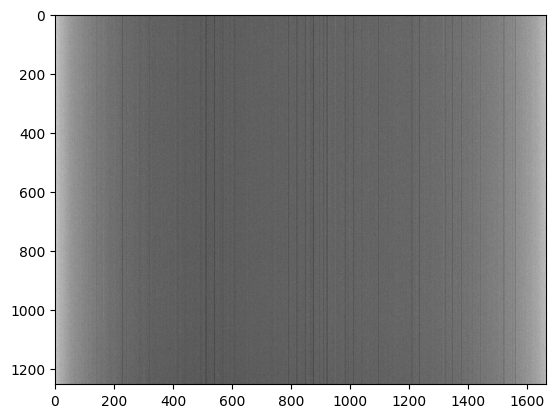

In [ ]:
vmin_b, vmax_b = zscale.get_limits(biases.flatten())
plt.imshow(master_bias, vmin=vmin_b, vmax=vmax_b, cmap='gray')

#### normalized flat-fields

create normalized flat-field with average intensity of 1 for each filter:

*   average all flats in filter
*   subtract master bias
*   divide by average value over all pixels
*   check that average intensity = 1



##### flats: filter g

In [ ]:
index_g = [i for i, filepath in enumerate(flats_files) if 'Flat_g' in filepath]
index_g

[0, 1, 2, 3, 4]

In [ ]:
master_flat_g = np.mean(flats[index_g], axis=0)
master_flat_g = master_flat_g-master_bias
master_flat_g_norm = master_flat_g/np.mean(master_flat_g)

np.mean(master_flat_g_norm)

np.float64(1.0)

##### flats: filter r

In [ ]:
index_r = [i for i, filepath in enumerate(flats_files) if 'Flat_r' in filepath]
index_r

[5, 6, 7, 8, 9]

In [ ]:
master_flat_r = np.mean(flats[index_r], axis=0)
master_flat_r = master_flat_r-master_bias
master_flat_r_norm = master_flat_r/np.mean(master_flat_r)

np.mean(master_flat_r_norm)

np.float64(1.0000000000000009)

##### flats: filter i

In [ ]:
index_i = [i for i, filepath in enumerate(flats_files) if 'Flat_i' in filepath]
index_i

[10, 11, 12, 13, 14]

In [ ]:
master_flat_i = np.mean(flats[index_i], axis=0)
master_flat_i = master_flat_i-master_bias
master_flat_i_norm = master_flat_i/np.mean(master_flat_i)

np.mean(master_flat_i_norm)

np.float64(0.9999999999999988)

#### reduce science images

* subtract master bias
* divide by normalized master flat for each filter

##### filter: g

In [ ]:
idx_g_15 = [i for i, filepath in enumerate(m2_files) if 'm2_g_15s' in filepath]
idx_g_30 = [i for i, filepath in enumerate(m2_files) if 'm2_g_30s' in filepath]
idx_g_15, idx_g_30

([1], [0])

In [ ]:
m2_g_15 = m2[idx_g_15[0]]
m2_g_30 = m2[idx_g_30[0]]
m2_g_15.shape, m2_g_30.shape

((1252, 1663), (1252, 1663))

In [ ]:
m2_g_15 = (m2_g_15-master_bias)/master_flat_g_norm
m2_g_30 = (m2_g_30-master_bias)/master_flat_g_norm
m2_g_15.shape, m2_g_30.shape

((1252, 1663), (1252, 1663))

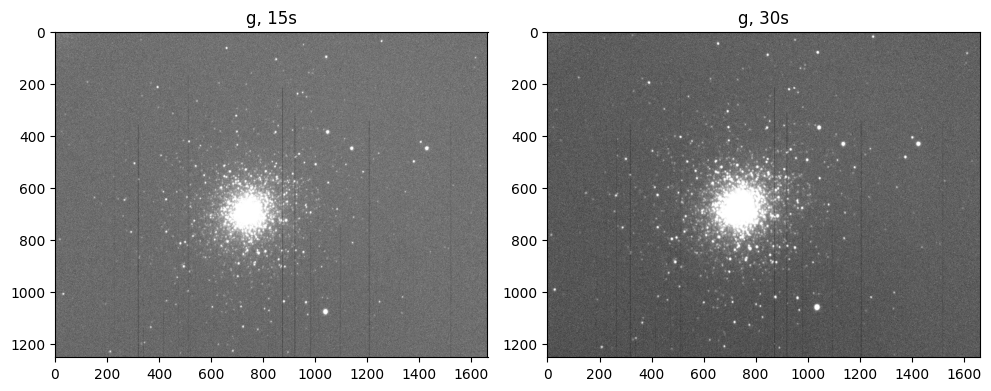

In [ ]:
# g filter
fig, axes = plt.subplots(1, 2, figsize=(10, 15))
axes = axes.flatten()

vmin_g_15, vmax_g_15 = zscale.get_limits(m2_g_15.flatten())
axes[0].imshow(m2_g_15, vmin=vmin_g_15, vmax=vmax_g_15, cmap='gray')
axes[0].set_title('g, 15s')

vmin_g_30, vmax_g_30 = zscale.get_limits(m2_g_30.flatten())
axes[1].imshow(m2_g_30, vmin=vmin_g_30, vmax=vmax_g_30, cmap='gray')
axes[1].set_title('g, 30s')

plt.tight_layout()
plt.show()

##### filter: r

In [ ]:
idx_r_15 = [i for i, filepath in enumerate(m2_files) if 'm2_r_15s' in filepath]
idx_r_30 = [i for i, filepath in enumerate(m2_files) if 'm2_r_30s' in filepath]
idx_r_15, idx_r_30

([2], [3])

In [ ]:
m2_r_15 = m2[idx_r_15[0]]
m2_r_30 = m2[idx_r_30[0]]
m2_r_15.shape, m2_r_30.shape

((1252, 1663), (1252, 1663))

In [ ]:
m2_r_15 = (m2_r_15-master_bias)/master_flat_r_norm
m2_r_30 = (m2_r_30-master_bias)/master_flat_r_norm
m2_r_15.shape, m2_r_30.shape

((1252, 1663), (1252, 1663))

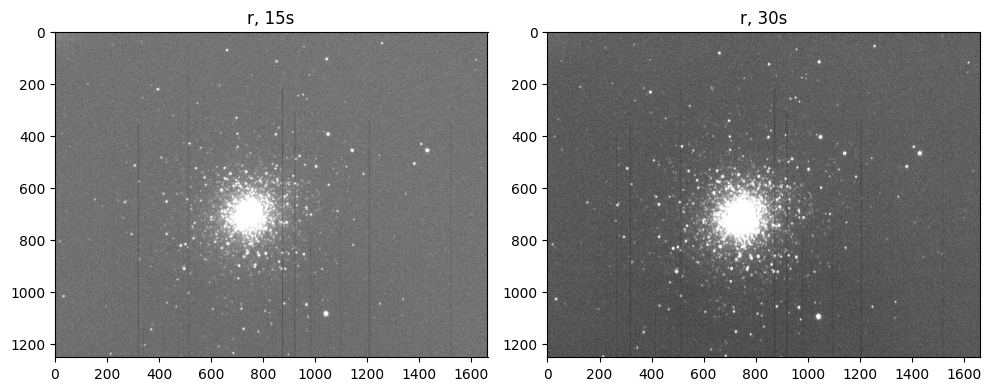

In [ ]:
# r filter
fig, axes = plt.subplots(1, 2, figsize=(10, 15))
axes = axes.flatten()

vmin_r_15, vmax_r_15 = zscale.get_limits(m2_r_15.flatten())
axes[0].imshow(m2_r_15, vmin=vmin_r_15, vmax=vmax_r_15, cmap='gray')
axes[0].set_title('r, 15s')

vmin_r_30, vmax_r_30 = zscale.get_limits(m2_r_30.flatten())
axes[1].imshow(m2_r_30, vmin=vmin_r_30, vmax=vmax_r_30, cmap='gray')
axes[1].set_title('r, 30s')

plt.tight_layout()
plt.show()

##### filter: i

In [ ]:
idx_i_15 = [i for i, filepath in enumerate(m2_files) if 'm2_i_15s' in filepath]
idx_i_30 = [i for i, filepath in enumerate(m2_files) if 'm2_i_30s' in filepath]
idx_i_15, idx_i_30

([5], [4])

In [ ]:
m2_i_15 = m2[idx_i_15[0]]
m2_i_30 = m2[idx_i_30[0]]
m2_i_15.shape, m2_i_30.shape

((1252, 1663), (1252, 1663))

In [ ]:
m2_i_15 = (m2_i_15-master_bias)/master_flat_i_norm
m2_i_30 = (m2_i_30-master_bias)/master_flat_i_norm
m2_i_15.shape, m2_i_30.shape

((1252, 1663), (1252, 1663))

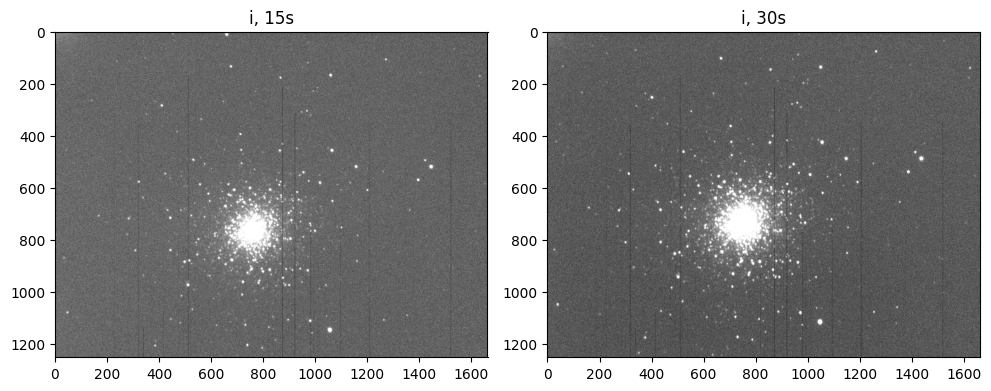

In [ ]:
# i filter
fig, axes = plt.subplots(1, 2, figsize=(10, 15))
axes = axes.flatten()

vmin_i_15, vmax_i_15 = zscale.get_limits(m2_i_15.flatten())
axes[0].imshow(m2_i_15, vmin=vmin_i_15, vmax=vmax_i_15, cmap='gray')
axes[0].set_title('i, 15s')

vmin_i_30, vmax_i_30 = zscale.get_limits(m2_i_30.flatten())
axes[1].imshow(m2_i_30, vmin=vmin_i_30, vmax=vmax_i_30, cmap='gray')
axes[1].set_title('i, 30s')

plt.tight_layout()
plt.show()

plot for report:

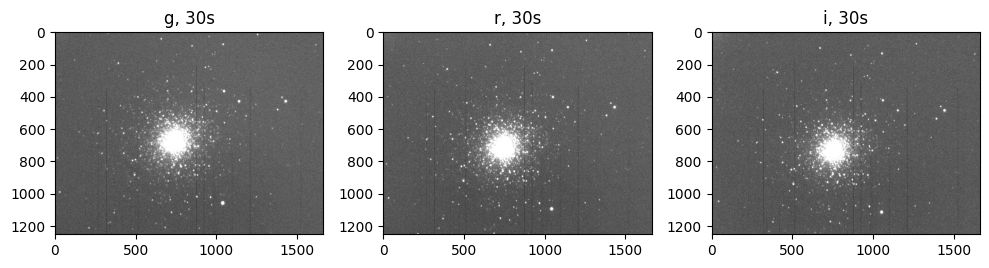

In [ ]:
# 3 filter plot

fig, axes = plt.subplots(1, 3, figsize=(10, 15))
axes = axes.flatten()

axes[0].imshow(m2_g_30, vmin=vmin_g_30, vmax=vmax_g_30, cmap='gray')
axes[0].set_title('g, 30s')

axes[1].imshow(m2_r_30, vmin=vmin_r_30, vmax=vmax_r_30, cmap='gray')
axes[1].set_title('r, 30s')

axes[2].imshow(m2_i_30, vmin=vmin_i_30, vmax=vmax_i_30, cmap='gray')
axes[2].set_title('i, 30s')

plt.tight_layout()
plt.show()

### photometry (Q3)

#### estimating sky background (a)

In [ ]:
mean_g, median_g, std_g = sigma_clipped_stats(m2_g_30, sigma=3.0)
sky_subtracted_image_g = m2_g_30 - median_g
median_g

np.float64(795.6561289055426)

In [ ]:
mean_r, median_r, std_r = sigma_clipped_stats(m2_r_30, sigma=3.0)
sky_subtracted_image_r = m2_r_30 - median_r
median_r

np.float64(679.0807027328991)

In [ ]:
mean_i, median_i, std_i = sigma_clipped_stats(m2_i_30, sigma=3.0)
sky_subtracted_image_i = m2_i_30 - median_i
median_i

np.float64(201.39917708801687)

#### source detection (b)

##### filter: g

In [ ]:
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std_g)
sources_g = daofind(sky_subtracted_image_g)

for col in sources_g.colnames:
  if col not in ('id', 'npix'):
    sources_g[col].info.format = '%.2f'

sources_g

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,1252.07,21.30,0.39,0.19,0.51,25,514.07,8917.83,-9.88,-0.21
2,656.96,47.91,0.30,0.18,0.47,25,596.04,10768.88,-10.08,-0.43
3,1282.00,63.08,0.94,-0.06,-0.33,25,219.64,-55.18,nan,-0.16
4,1039.34,81.52,0.30,0.58,0.40,25,1086.16,19498.39,-10.72,-1.17
5,847.23,90.94,0.43,0.53,0.35,25,559.10,9263.14,-9.92,-0.39
6,391.62,197.85,0.40,0.41,0.12,25,629.21,10889.30,-10.09,-0.48
7,929.06,222.84,0.43,0.09,0.14,25,466.71,7809.82,-9.73,-0.21
8,123.95,251.30,0.92,0.34,-0.37,25,266.88,95.03,-4.94,-0.42
9,612.40,304.28,0.96,-0.10,-0.05,25,200.72,111.66,-5.12,-0.03


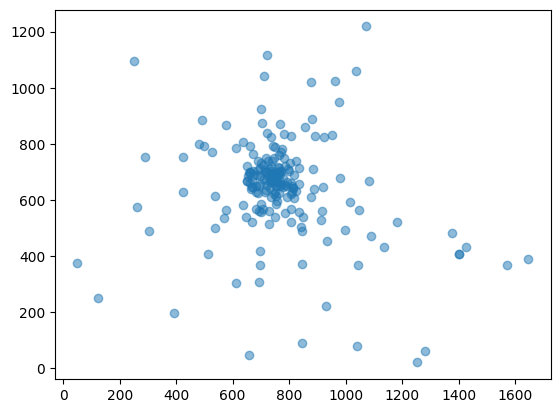

In [ ]:
# scatterplot of positions: g

plt.scatter(sources_g['xcentroid'], sources_g['ycentroid'], alpha=0.5)

##### filter: r

In [ ]:
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std_r)
sources_r = daofind(sky_subtracted_image_r)

for col in sources_r.colnames:
  if col not in ('id', 'npix'):
    sources_r[col].info.format = '%.2f'

sources_r

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,144.06,12.88,0.85,-0.85,-0.04,25,173.13,235.39,-5.93,-0.01
2,1257.56,57.32,0.53,0.43,0.46,25,902.82,13121.27,-10.29,-1.10
3,957.58,69.93,0.24,0.28,0.36,25,246.54,4147.58,-9.04,-0.11
4,662.24,84.05,0.43,0.44,0.34,25,1346.04,20727.94,-10.79,-1.59
5,395.38,110.22,0.58,-0.12,-0.03,25,62879.29,232536.35,-13.42,-6.59
6,1044.88,117.70,0.43,0.47,0.48,25,2925.06,43364.89,-11.59,-2.48
7,1618.31,120.74,0.49,-0.21,0.12,25,374.17,5335.66,-9.32,-0.24
8,852.62,126.82,0.41,0.59,0.30,25,881.55,14540.68,-10.41,-1.08
9,251.52,200.02,0.47,-0.58,-0.03,25,63494.60,321595.21,-13.77,-6.67


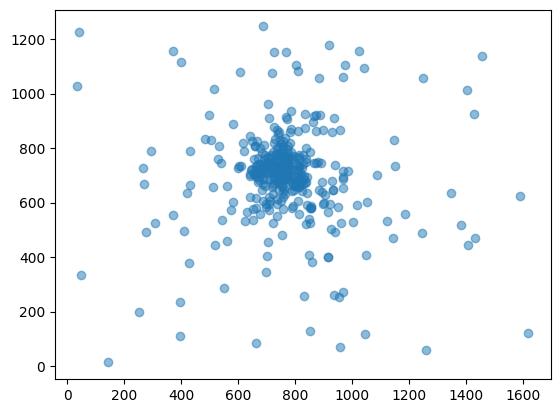

In [ ]:
# scatterplot of positions: r

plt.scatter(sources_r['xcentroid'], sources_r['ycentroid'], alpha=0.5)

##### filter: i

In [ ]:
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std_i)
sources_i = daofind(sky_subtracted_image_i)

for col in sources_i.colnames:
  if col not in ('id', 'npix'):
    sources_i[col].info.format = '%.2f'

sources_i

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
1,1279.25,16.91,0.97,-0.63,0.18,25,137.21,390.93,-6.48,-0.01
2,342.34,23.88,0.95,-0.16,0.06,25,123.03,105.08,-5.05,-0.14
3,339.01,48.03,0.92,0.45,0.28,25,104.62,40.69,-4.02,-0.02
4,1004.00,62.92,0.71,0.28,0.34,25,93.81,150.28,-5.44,-0.08
5,971.17,70.00,0.98,0.22,-0.14,25,166.21,201.44,-5.76,-0.30
6,991.11,72.67,0.96,0.57,0.39,25,123.94,256.90,-6.02,-0.08
7,1263.51,77.80,0.28,0.21,0.55,25,379.39,6577.92,-9.55,-0.78
8,109.00,80.03,0.95,-0.02,-0.14,25,123.87,223.98,-5.88,-0.01
9,963.70,90.43,0.51,0.32,0.23,25,148.84,1949.11,-8.22,-0.03


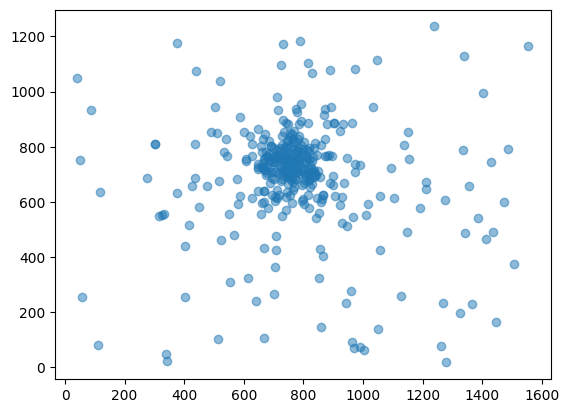

In [ ]:
# scatterplot of positions: i

plt.scatter(sources_i['xcentroid'], sources_i['ycentroid'], alpha=0.5)

plot for report:

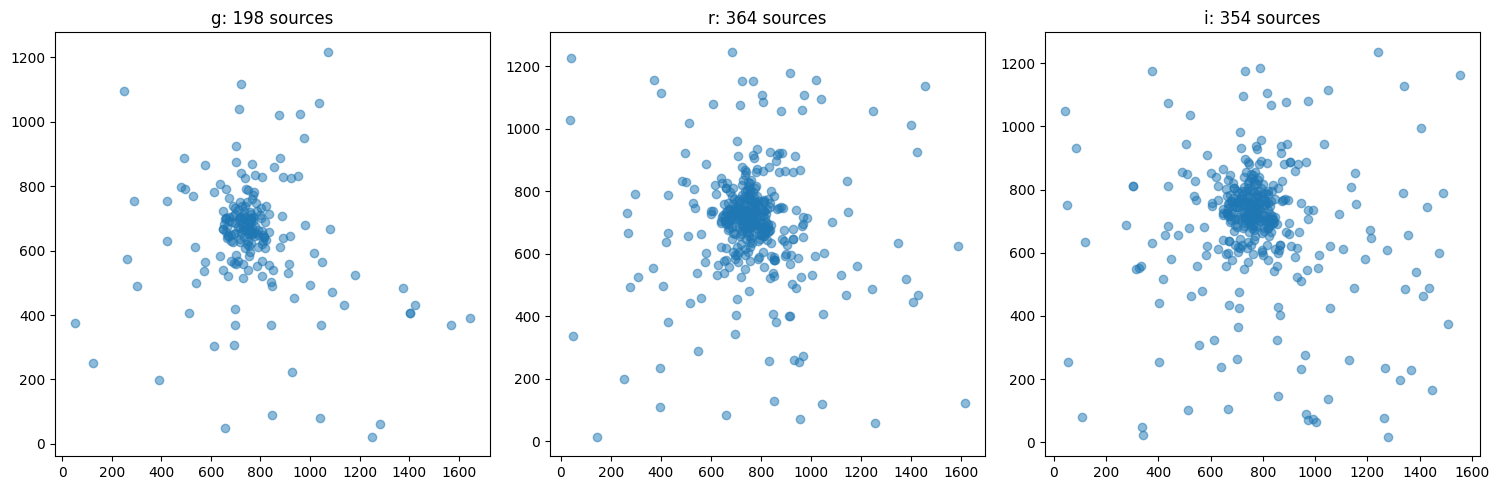

In [ ]:
# 3 filter plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

axes[0].scatter(sources_g['xcentroid'], sources_g['ycentroid'], alpha=0.5)
axes[0].set_title('g: 198 sources')

axes[1].scatter(sources_r['xcentroid'], sources_r['ycentroid'], alpha=0.5)
axes[1].set_title('r: 364 sources')

axes[2].scatter(sources_i['xcentroid'], sources_i['ycentroid'], alpha=0.5)
axes[2].set_title('i: 354 sources')

plt.tight_layout()
plt.show()

#### aperture photometry (c)

##### filter: g

In [ ]:
positions_g = [ (s['xcentroid'], s['ycentroid']) for s in sources_g ]
apertures_g = CircularAperture(positions_g, r=4.0)

photometry_table_g = aperture_photometry(sky_subtracted_image_g, apertures_g)
photometry_table_g['aperture_sum'].info.format = '%.8g'
photometry_table_g

id,xcenter,ycenter,aperture_sum
int64,float64,float64,float64
1,1252.0703549674392,21.295477023260254,13798.001
2,656.9629559520071,47.91305638354689,17146.71
3,1282.000411529866,63.078379491716895,97.384422
4,1039.3423661827562,81.52268315190702,29368.701
5,847.2285899882013,90.9371118268406,13624.213
6,391.6207013274769,197.85046362811903,16842.494
7,929.0596945057671,222.84266791553574,12499.91
8,123.95200979050432,251.30242778638362,18.321396
9,612.3972987275466,304.2824173251802,56.628483


In [ ]:
sources_g['aperture_sum'] = photometry_table_g['aperture_sum']
sources_g['mag_calculated'] = -2.5*np.log10(sources_g['aperture_sum'])
sources_g

/tmp/ipython-input-2689099346.py:2: RuntimeWarning: invalid value encountered in log10
  sources_g['mag_calculated'] = -2.5*np.log10(sources_g['aperture_sum'])


id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,mag_calculated
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
1,1252.07,21.30,0.39,0.19,0.51,25,514.07,8917.83,-9.88,-0.21,13798.001,-10.34954
2,656.96,47.91,0.30,0.18,0.47,25,596.04,10768.88,-10.08,-0.43,17146.71,-10.585452
3,1282.00,63.08,0.94,-0.06,-0.33,25,219.64,-55.18,nan,-0.16,97.384422,-4.9712237
4,1039.34,81.52,0.30,0.58,0.40,25,1086.16,19498.39,-10.72,-1.17,29368.701,-11.169712
5,847.23,90.94,0.43,0.53,0.35,25,559.10,9263.14,-9.92,-0.39,13624.213,-10.335779
6,391.62,197.85,0.40,0.41,0.12,25,629.21,10889.30,-10.09,-0.48,16842.494,-10.566016
7,929.06,222.84,0.43,0.09,0.14,25,466.71,7809.82,-9.73,-0.21,12499.91,-10.242267
8,123.95,251.30,0.92,0.34,-0.37,25,266.88,95.03,-4.94,-0.42,18.321396,-3.1573964
9,612.40,304.28,0.96,-0.10,-0.05,25,200.72,111.66,-5.12,-0.03,56.628483,-4.3825873


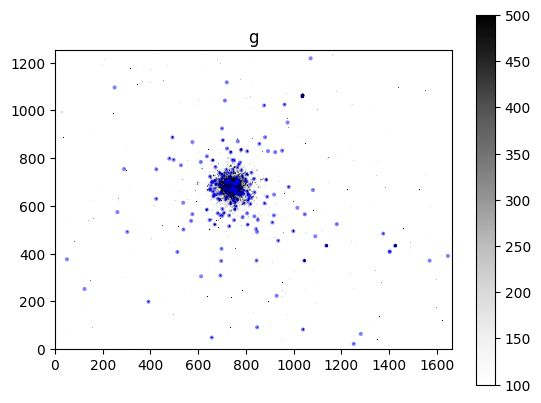

In [ ]:
plt.imshow(sky_subtracted_image_g, cmap='Greys', origin='lower', vmin=100,vmax=500,
           interpolation='nearest')
plt.colorbar()
apertures_g.plot(color='blue', lw=1.5, alpha=0.5)
plt.title('g')
plt.show()

##### filter: r

In [ ]:
positions_r = [ (s['xcentroid'],s['ycentroid']) for s in sources_r ]
apertures_r = CircularAperture(positions_r, r=4.0)

photometry_table_r = aperture_photometry(sky_subtracted_image_r, apertures_r)
photometry_table_r['aperture_sum'].info.format = '%.8g'
photometry_table_r

id,xcenter,ycenter,aperture_sum
int64,float64,float64,float64
1,144.0600776223083,12.880130975199544,380.21595
2,1257.5564970255718,57.322425361262205,18620.109
3,957.5811563408589,69.92749531804786,5957.1782
4,662.2353670665294,84.04711755062685,29101.032
5,395.3764217992481,110.222298345462,232655.78
6,1044.880284973651,117.70276825110628,59409.666
7,1618.3068741696593,120.73592863761469,7859.2179
8,852.6232784791329,126.81766008111967,20308.48
9,251.5215801138343,200.02088946669485,321799.53


In [ ]:
sources_r['aperture_sum'] = photometry_table_r['aperture_sum']
sources_r['mag_calculated'] = -2.5*np.log10(sources_r['aperture_sum'])
sources_r

/tmp/ipython-input-3566747338.py:2: RuntimeWarning: invalid value encountered in log10
  sources_r['mag_calculated'] = -2.5*np.log10(sources_r['aperture_sum'])


id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,mag_calculated
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
1,144.06,12.88,0.85,-0.85,-0.04,25,173.13,235.39,-5.93,-0.01,380.21595,-6.4500758
2,1257.56,57.32,0.53,0.43,0.46,25,902.82,13121.27,-10.29,-1.10,18620.109,-10.674956
3,957.58,69.93,0.24,0.28,0.36,25,246.54,4147.58,-9.04,-0.11,5957.1782,-9.4376015
4,662.24,84.05,0.43,0.44,0.34,25,1346.04,20727.94,-10.79,-1.59,29101.032,-11.159771
5,395.38,110.22,0.58,-0.12,-0.03,25,62879.29,232536.35,-13.42,-6.59,232655.78,-13.416785
6,1044.88,117.70,0.43,0.47,0.48,25,2925.06,43364.89,-11.59,-2.48,59409.666,-11.934643
7,1618.31,120.74,0.49,-0.21,0.12,25,374.17,5335.66,-9.32,-0.24,7859.2179,-9.7384483
8,852.62,126.82,0.41,0.59,0.30,25,881.55,14540.68,-10.41,-1.08,20308.48,-10.769194
9,251.52,200.02,0.47,-0.58,-0.03,25,63494.60,321595.21,-13.77,-6.67,321799.53,-13.768964


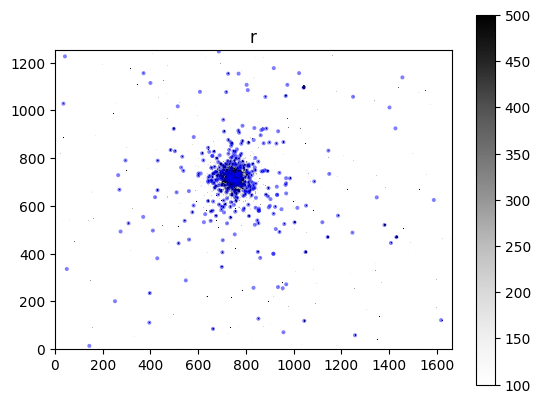

In [ ]:
plt.imshow(sky_subtracted_image_r, cmap='Greys', origin='lower', vmin=100,vmax=500,
           interpolation='nearest')
plt.colorbar()
apertures_r.plot(color='blue', lw=1.5, alpha=0.5)
plt.title('r')
plt.show()

##### filter: i

In [ ]:
positions_i = [ (s['xcentroid'], s['ycentroid']) for s in sources_i ]
apertures_i = CircularAperture(positions_i, r=4.0)

photometry_table_i = aperture_photometry(sky_subtracted_image_i, apertures_i)
photometry_table_i['aperture_sum'].info.format = '%.8g'
photometry_table_i

id,xcenter,ycenter,aperture_sum
int64,float64,float64,float64
1,1279.2519984470873,16.912120753029264,591.97171
2,342.3379154863024,23.87626393459714,141.04741
3,339.01219079063594,48.02576547421889,44.034709
4,1004.0046639299528,62.920535837934786,285.97166
5,971.1696980660253,69.99534494115566,126.92539
6,991.1060614587486,72.67468389995663,228.69115
7,1263.5135151504721,77.79594977605868,9592.0145
8,109.00216977175388,80.02697256060135,352.29319
9,963.7042832264747,90.43086488521834,2790.8418


In [ ]:
sources_i['aperture_sum'] = photometry_table_i['aperture_sum']
sources_i['mag_calculated'] = -2.5*np.log10(sources_i['aperture_sum'])
sources_i

/tmp/ipython-input-2883397076.py:2: RuntimeWarning: invalid value encountered in log10
  sources_i['mag_calculated'] = -2.5*np.log10(sources_i['aperture_sum'])


id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,mag_calculated
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
1,1279.25,16.91,0.97,-0.63,0.18,25,137.21,390.93,-6.48,-0.01,591.97171,-6.9307524
2,342.34,23.88,0.95,-0.16,0.06,25,123.03,105.08,-5.05,-0.14,141.04741,-5.3734128
3,339.01,48.03,0.92,0.45,0.28,25,104.62,40.69,-4.02,-0.02,44.034709,-4.1094878
4,1004.00,62.92,0.71,0.28,0.34,25,93.81,150.28,-5.44,-0.08,285.97166,-6.1408075
5,971.17,70.00,0.98,0.22,-0.14,25,166.21,201.44,-5.76,-0.30,126.92539,-5.2588713
6,991.11,72.67,0.96,0.57,0.39,25,123.94,256.90,-6.02,-0.08,228.69115,-5.8981234
7,1263.51,77.80,0.28,0.21,0.55,25,379.39,6577.92,-9.55,-0.78,9592.0145,-9.9547746
8,109.00,80.03,0.95,-0.02,-0.14,25,123.87,223.98,-5.88,-0.01,352.29319,-6.3672606
9,963.70,90.43,0.51,0.32,0.23,25,148.84,1949.11,-8.22,-0.03,2790.8418,-8.614338


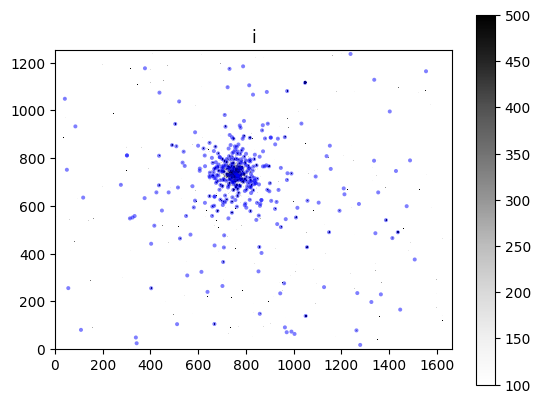

In [ ]:
plt.imshow(sky_subtracted_image_i, cmap='Greys', origin='lower', vmin=100,vmax=500,
           interpolation='nearest')
plt.colorbar()
apertures_i.plot(color='blue', lw=1.5, alpha=0.5)
plt.title('i')
plt.show()

### uncertainties for source fluxes (Q4)

$$N = \sqrt{S_* + n_{pix}(S_{sky} + \sigma_R^2)}$$

##### filter: g

In [ ]:
R = np.std(master_bias) # readnoise
gain = 1.0
npix = np.pi * 4**2 # aperture size in pixels, circular aperture radius=4
S_source_g = sources_g['aperture_sum']
skylevel_g = median_g
Noise_g = np.sqrt( gain*S_source_g + npix*(gain*skylevel_g + R**2) ) / gain
Noise_g

<Column name='aperture_sum' dtype='float64' format='%.8g' length=198>
238.38274
245.30602
207.66732
269.06697
238.01795
244.68516
235.64431
207.47687
207.56917
238.08725
236.37688
245.16097
      ...
260.28976
  233.797
233.40093
206.36196
245.37256
252.94895
 227.2723
 773.7697
206.86733
234.06607
207.58626

Text(0.5, 1.0, 'g')

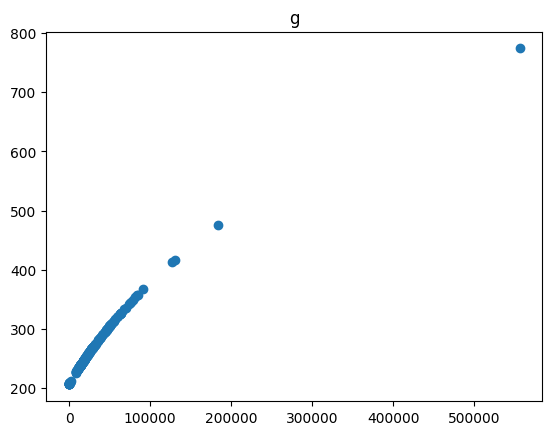

In [ ]:
# plot S/N

S_source_g.sort()
Noise_g.sort()
plt.scatter(S_source_g, Noise_g)
plt.title('g')

##### filter: r

In [ ]:
R = np.std(master_bias) # readnoise
gain = 1.0
npix = np.pi * 4**2 # aperture size in pixels, circular aperture radius=4
S_source_r = sources_r['aperture_sum']
skylevel_r = median_r
Noise_r = np.sqrt( gain*S_source_r + npix*(gain*skylevel_r + R**2) ) / gain
Noise_r

<Column name='aperture_sum' dtype='float64' format='%.8g' length=364>
 193.7752
236.19636
 207.6675
257.42891
519.44624
310.77046
212.19762
 239.7438
 599.1395
257.62637
219.61386
 194.2225
      ...
192.27146
210.67917
192.16674
193.15615
237.87232
190.77455
216.09419
191.03843
192.49703
192.27826
218.56202

Text(0.5, 1.0, 'r')

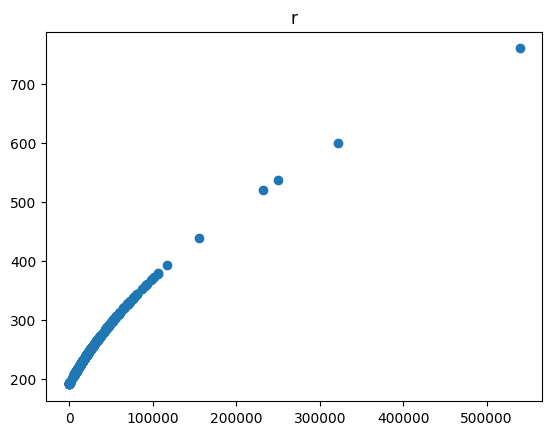

In [ ]:
# plot S/N

plt.scatter(S_source_r, Noise_r)
plt.title('r')

##### filter: i

In [ ]:
R = np.std(master_bias) # readnoise
gain = 1.0
npix = np.pi * 4**2 # aperture size in pixels, circular aperture radius=4
S_source_i = sources_i['aperture_sum']
skylevel_i = median_i
Noise_i = np.sqrt( gain*S_source_i + npix*(gain*skylevel_i + R**2) ) / gain
Noise_i

<Column name='aperture_sum' dtype='float64' format='%.8g' length=354>
117.25908
115.32028
114.89889
115.94693
115.25903
115.69966
150.83015
116.23258
126.28761
115.32585
175.75818
229.55052
      ...
137.46583
194.19627
145.19213
134.41353
504.86605
  115.154
114.34076
  156.962
136.72318
134.03532
114.01615

Text(0.5, 1.0, 'i')

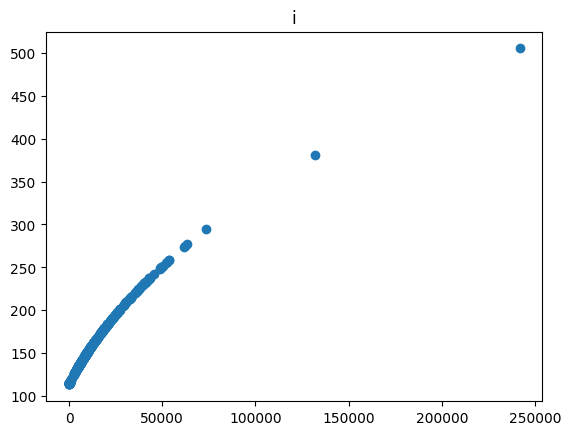

In [ ]:
# plot S/N

plt.scatter(S_source_i, Noise_i)
plt.title('i')

## data analysis 2: create a color-magnitude diagram and compare with isochrones

### convert flux & flux uncertainties (Q1)

convert flux to instrumental magnitude:
$$m_{inst} = -2.5 \times log_{10}(I)$$

convert flux uncertainties to uncertainties in magnitudes:
$$\sigma_m = 1.086(\frac{\sigma_I}{I})$$
where $I$=signal, $\sigma_I$=noise for a given source

In [ ]:
mag_inst_r = -2.5*np.log10(S_source_r)
mag_uncert_r = 1.086*(Noise_r/S_source_r)

/tmp/ipython-input-2785313311.py:1: RuntimeWarning: invalid value encountered in log10
  mag_inst_r = -2.5*np.log10(S_source_r)


In [ ]:
mag_inst_i = -2.5*np.log10(S_source_i)
mag_uncert_i = 1.086*(Noise_i/S_source_i)

/tmp/ipython-input-1638109370.py:1: RuntimeWarning: invalid value encountered in log10
  mag_inst_i = -2.5*np.log10(S_source_i)


### catalog matching (Q3)

In [ ]:
len(sources_r), len(sources_i)

(364, 354)

In [ ]:
image_fit_i = fits.open('drive/MyDrive/astro465/lab3/data3/m2/20251005_022009_m2_i_30s_2x2.fits')
image_fit_r = fits.open('drive/MyDrive/astro465/lab3/data3/m2/20251005_021806_m2_r_30s_2x2.fits')

In [ ]:
wcs_r = astropy.wcs.WCS(image_fit_r[0].header)
src_r = wcs_r.pixel_to_world(sources_r['xcentroid'], sources_r['ycentroid'])

wcs_i = astropy.wcs.WCS(image_fit_i[0].header)
src_i = wcs_i.pixel_to_world(sources_i['xcentroid'], sources_i['ycentroid'])

In [ ]:
# convert to sky coordinates (ra, dec)

pixelscale=1*u.arcsec
src_i = astcoo.SkyCoord(sources_i['xcentroid']*pixelscale, sources_i['ycentroid']*pixelscale, frame='icrs')
src_r = astcoo.SkyCoord(sources_r['xcentroid']*pixelscale, sources_r['ycentroid']*pixelscale, frame='icrs')

In [ ]:
idx_i, d2d_i, d3d = src_r .match_to_catalog_sky(src_i)
len(idx_i), len(src_r), len(src_i)

(364, 364, 354)

In [ ]:
matched_catalog_i = sources_i[idx_i]

sources_r['mag_r'] = sources_r['mag']
sources_r['mag_i'] = matched_catalog_i['mag']
sources_r['d2d_i'] = d2d_i.arcsec

In [ ]:
sources_r

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,mag_calculated,mag_r,mag_i,d2d_i
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,144.06,12.88,0.85,-0.85,-0.04,25,173.13,235.39,-5.93,-0.01,380.21595,-6.4500758,-5.93,-5.88,75.74797135607001
2,1257.56,57.32,0.53,0.43,0.46,25,902.82,13121.27,-10.29,-1.10,18620.109,-10.674956,-10.29,-9.55,21.322552920970317
3,957.58,69.93,0.24,0.28,0.36,25,246.54,4147.58,-9.04,-0.11,5957.1782,-9.4376015,-9.04,-5.76,13.588710334137577
4,662.24,84.05,0.43,0.44,0.34,25,1346.04,20727.94,-10.79,-1.59,29101.032,-11.159771,-10.79,-10.17,21.44037627544251
5,395.38,110.22,0.58,-0.12,-0.03,25,62879.29,232536.35,-13.42,-6.59,232655.78,-13.416785,-13.42,-4.02,83.93649234291696
6,1044.88,117.70,0.43,0.47,0.48,25,2925.06,43364.89,-11.59,-2.48,59409.666,-11.934643,-11.59,-11.14,21.439935434009517
7,1618.31,120.74,0.49,-0.21,0.12,25,374.17,5335.66,-9.32,-0.24,7859.2179,-9.7384483,-9.32,-6.12,177.01525354051046
8,852.62,126.82,0.41,0.59,0.30,25,881.55,14540.68,-10.41,-1.08,20308.48,-10.769194,-10.41,-9.80,21.31989938502507
9,251.52,200.02,0.47,-0.58,-0.03,25,63494.60,321595.21,-13.77,-6.67,321799.53,-13.768964,-13.77,-10.23,161.10706431297595


In [ ]:
len(sources_r)

364

### color-magnitude diagram (Q4)

(array([235., 102.,   9.,   3.,   6.,   4.,   2.,   0.,   0.,   3.]),
 array([  0.26878765,  18.0092431 ,  35.74969855,  53.490154  ,
         71.23060945,  88.97106489, 106.71152034, 124.45197579,
        142.19243124, 159.93288669, 177.67334214]),
 <BarContainer object of 10 artists>)

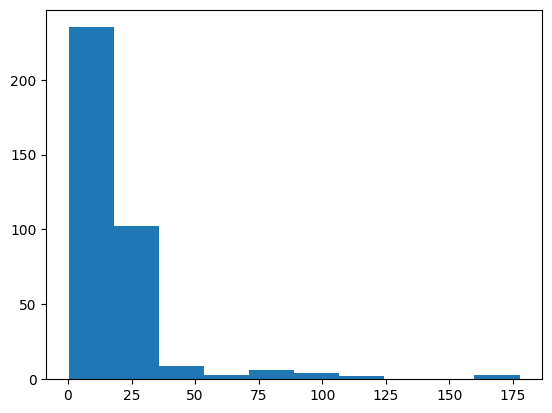

In [ ]:
plt.hist(d2d_i.arcsec)

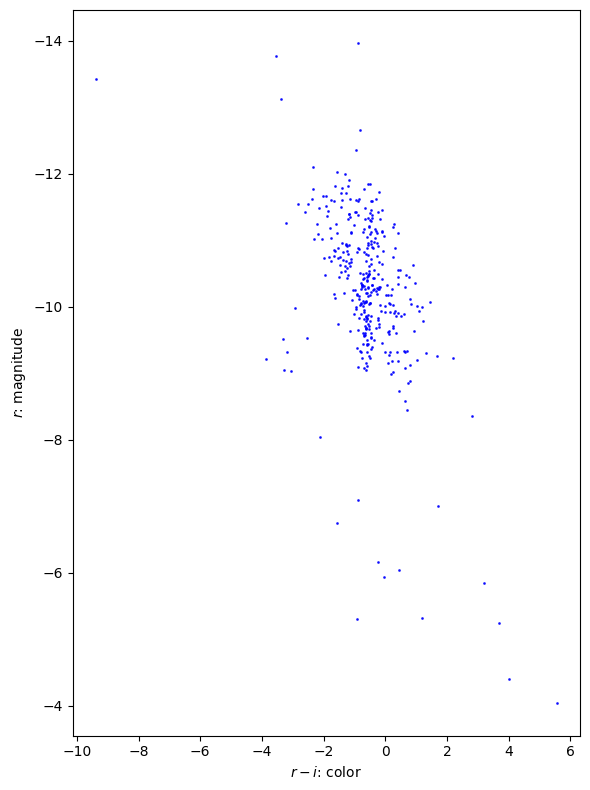

In [ ]:
plt.figure(figsize=(6,8))

i=sources_r['mag_i']
r=sources_r['mag_r']
r_i=r-i

plt.scatter(r_i, r, s=1, alpha=0.8, color='blue')

plt.xlabel('$r - i$: color')
plt.ylabel('$r$: magnitude')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

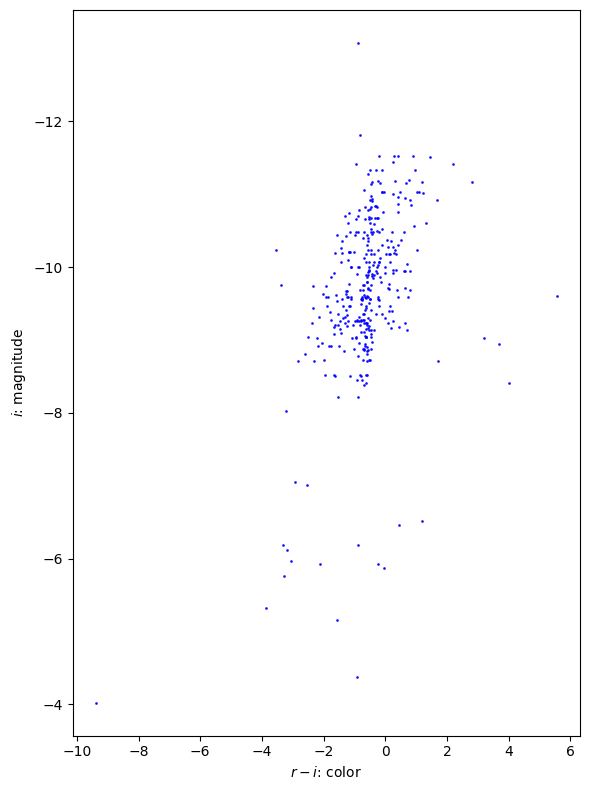

In [112]:
plt.figure(figsize=(6,8))

i=sources_r['mag_i']
r=sources_r['mag_r']
r_i=r-i

plt.scatter(r_i, i, s=1, alpha=0.8, color='blue')

plt.xlabel('$r - i$: color')
plt.ylabel('$i$: magnitude')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### isochrone matching (Q5) - optional

In [110]:
! pip install uwastro465isos # from Ralf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 48.6 MB/s eta 0:00:00


In [111]:
# import the package
from uwastro465isos import isochrones
# initiate the isochrone class -- there are two options
# Isochrone_Johnson is you are using archival data from WIYN, in the B/V/R/I filters
# Isochrone_Sloan if you are using roof-top data in u/g/r/i/z filters
iso = isochrones.Isochrone_Sloan()
# you can query the class to what ages and metallicities are available:
# for log(ages)
iso.get_list_of_ages()
# for different magnitude bandpasses
iso.get_list_of_magnitudes()
# and for metalliticities
iso.get_list_of_metallicities()
# get data for a single isochrone with a given log(age) and metallicity
iso1 = iso.select_isochrone(9.1, -1.0)
iso1

/usr/local/lib/python3.12/dist-packages/uwastro465isos/isochrones.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.iso = pandas.read_csv(self.filename, delim_whitespace=True, comment='#', )


,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xn,Xo,Cexcess,Z,mbolmag,umag,gmag,rmag,imag,zmag
62335,0.001547,-1.0,9.1,0.090000,1.081690,0.090,-3.228,3.4448,5.352,0,...,0.000079,0.000717,-1.000,0.001629,12.840,22.155,17.534,15.507,13.416,12.356
62336,0.001547,-1.0,9.1,0.092279,1.103173,0.092,-3.181,3.4516,5.343,0,...,0.000079,0.000717,-1.000,0.001629,12.723,21.717,17.222,15.220,13.241,12.232
62337,0.001547,-1.0,9.1,0.093757,1.116733,0.094,-3.148,3.4564,5.335,0,...,0.000079,0.000717,-1.000,0.001629,12.639,21.393,16.999,15.011,13.118,12.145
62338,0.001547,-1.0,9.1,0.096838,1.144140,0.097,-3.076,3.4666,5.318,0,...,0.000079,0.000717,-1.000,0.001629,12.459,20.734,16.537,14.580,12.859,11.961
62339,0.001547,-1.0,9.1,0.100000,1.171106,0.100,-3.005,3.4767,5.301,0,...,0.000079,0.000717,-1.000,0.001629,12.281,20.106,16.092,14.169,12.608,11.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62729,0.001547,-1.0,9.1,1.799532,2.558918,0.963,3.911,3.4166,-0.872,8,...,0.000239,0.000935,9.127,0.013940,-5.008,20.670,10.798,5.953,3.409,1.363
62730,0.001547,-1.0,9.1,1.799541,2.558918,0.910,3.941,3.4123,-0.943,8,...,0.000239,0.000935,9.128,0.013970,-5.082,19.754,10.113,5.385,2.909,0.923
62731,0.001547,-1.0,9.1,1.799552,2.558919,0.853,3.954,3.4191,-0.957,8,...,0.000239,0.000936,9.131,0.014050,-5.115,15.284,6.985,2.915,0.827,-0.837
62732,0.001547,-1.0,9.1,1.799564,2.558919,0.793,3.961,3.4348,-0.933,8,...,0.000239,0.000938,9.136,0.014190,-5.133,22.608,12.165,7.022,4.341,2.157
